In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
%matplotlib inline

In [2]:
data_dir = 'dataset'

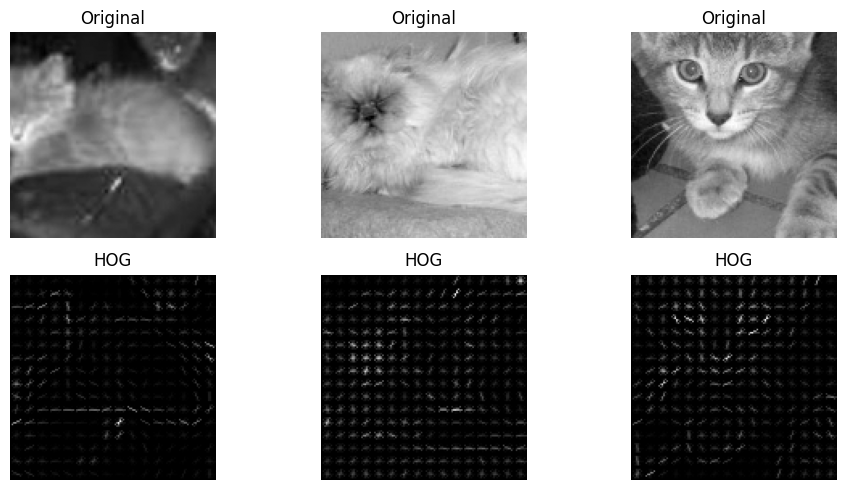

In [3]:
hog_features = []
hog_labels = []
plt.figure(figsize=(10, 5))
display_count = 0

for label in os.listdir(data_dir):
    for file in os.listdir(os.path.join(data_dir, label)):
        img_path = os.path.join(data_dir, label, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features, hog_img = hog(gray, orientations=9,
                                pixels_per_cell=(8, 8),
                                cells_per_block=(2, 2),
                                visualize=True)
        hog_features.append(features)
        hog_labels.append(label)

        if display_count < 3:
            plt.subplot(2, 3, display_count + 1)
            plt.imshow(gray, cmap='gray')
            plt.title('Original')
            plt.axis('off')
            plt.subplot(2, 3, display_count + 4)
            plt.imshow(hog_img, cmap='gray')
            plt.title('HOG')
            plt.axis('off')
            display_count += 1

plt.tight_layout()
plt.show()

In [4]:
hog_df = pd.DataFrame(hog_features)
hog_df['label'] = hog_labels
hog_df.to_csv('hog_features.csv', index=False)
hog_df.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,label
0,0.240115,0.049582,0.166406,0.228522,0.085257,0.112047,0.123646,0.030631,0.127996,0.240115,...,0.267175,0.108826,0.022922,0.070990,0.146121,0.057833,0.126032,0.267175,0.267175,cats
1,0.246328,0.146092,0.203380,0.039322,0.246328,0.122098,0.153763,0.114024,0.110440,0.246328,...,0.239036,0.099936,0.015706,0.112582,0.147466,0.124377,0.210449,0.172301,0.159693,cats
2,0.264571,0.104074,0.097956,0.047769,0.092152,0.021254,0.017850,0.264571,0.175991,0.264571,...,0.243310,0.147621,0.157591,0.113851,0.207914,0.085961,0.146793,0.140145,0.223546,cats
3,0.194581,0.189842,0.060347,0.107506,0.237094,0.044584,0.090193,0.086475,0.107748,0.216226,...,0.164400,0.221095,0.296485,0.036555,0.026321,0.012653,0.024017,0.002030,0.296485,cats
4,0.271983,0.033203,0.271983,0.271983,0.271983,0.271983,0.189139,0.099541,0.000000,0.271983,...,0.266745,0.172105,0.024371,0.082659,0.100768,0.025155,0.118126,0.205959,0.254185,cats


In [5]:
X = hog_df.drop('label', axis=1).values
y = hog_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_hog = SVC(kernel='rbf', probability=True)
svm_hog.fit(X_train, y_train)

y_pred = svm_hog.predict(X_test)
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

HOG Accuracy: 0.7375
              precision    recall  f1-score   support

        cats       0.73      0.75      0.74       199
        dogs       0.74      0.73      0.74       201

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400



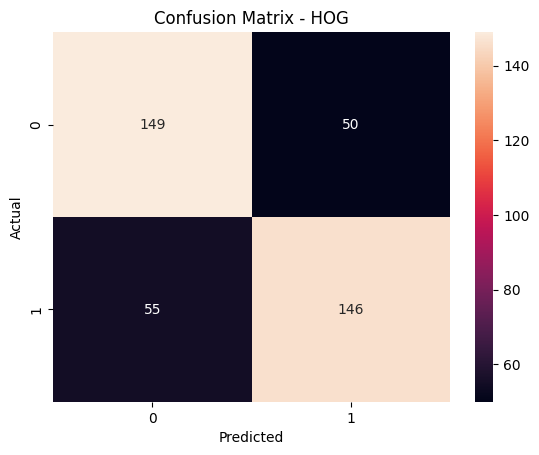

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - HOG')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

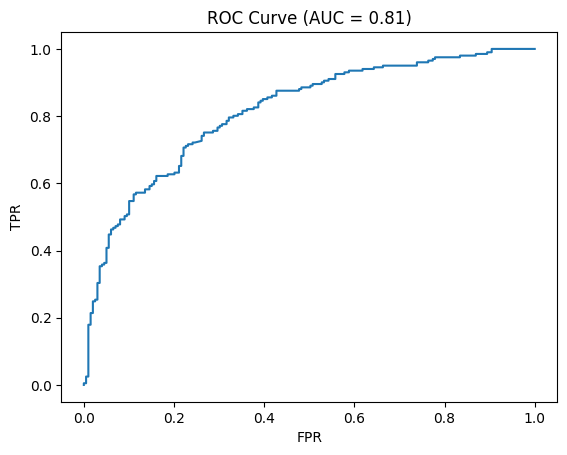

In [7]:
y_prob = svm_hog.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve((y_test=='dogs').astype(int), y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [8]:
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

cnn_features = []
cnn_labels = []

with torch.no_grad():
    for imgs, lbls in loader:
        output = model(imgs)
        output = output.view(output.size(0), -1)
        cnn_features.append(output.numpy())
        cnn_labels.append(lbls.numpy())

X_cnn = np.vstack(cnn_features)
y_cnn = np.hstack(cnn_labels)

C:\Users\Safi Ur Rehman\PycharmProjects\PythonProject17\.venv1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Safi Ur Rehman\PycharmProjects\PythonProject17\.venv1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42)

svm_cnn = SVC(kernel='rbf')
svm_cnn.fit(X_train_cnn, y_train_cnn)

y_pred_cnn = svm_cnn.predict(X_test_cnn)
print('CNN Feature Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))

CNN Feature Accuracy: 0.9675


In [12]:
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print('CNN Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))

HOG Accuracy: 0.7375
CNN Accuracy: 0.9675


In [33]:
import cv2
import torch
import numpy as np
from torchvision import models, transforms
from PIL import Image
from skimage.feature import hog

# ---------------------------
# HOG + SVM Prediction
# ---------------------------
img_path = r"C:\Users\Safi Ur Rehman\Desktop\test6.jpeg"
img = cv2.imread(img_path)
img = cv2.resize(img, (128, 128))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hog_features_test = hog(gray, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
hog_features_scaled = scaler.transform([hog_features_test])

hog_pred = svm_hog.predict(hog_features_scaled)

# Map HOG labels (string) to readable output
if hog_pred[0] == "cats":
    print("HOG Prediction: Cat")
else:
    print("HOG Prediction: Dog")

# ---------------------------
# CNN + SVM Prediction
# ---------------------------
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_pil = Image.open(img_path).convert("RGB")
img_tensor = cnn_transform(img_pil).unsqueeze(0)

with torch.no_grad():
    cnn_features = model(img_tensor)
cnn_features = cnn_features.view(cnn_features.size(0), -1).numpy()

cnn_pred = svm_cnn.predict(cnn_features)

# Map numeric CNN labels to readable output
if cnn_pred[0] == 0:
    print("CNN Prediction: Cat")
else:
    print("CNN Prediction: Dog")

HOG Prediction: Dog


C:\Users\Safi Ur Rehman\PycharmProjects\PythonProject17\.venv1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Safi Ur Rehman\PycharmProjects\PythonProject17\.venv1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


CNN Prediction: Dog
